# Domain Selection: Healthcare - Patient Intelligence
To Predict hospital readmission risk using patient demographics, medical history (structured), and clinical notes (textual) to support better resource allocation.

Step 5: Part A - Problem Framing, Data Mining, and Preparation (30 Marks)

## Question 1: Define the Analytical Problem (10 Marks)

### Selected Domain: Healthcare - Patient Intelligence

#### Analytical Problem Definition
The analytical problem addressed is predicting hospital readmission risk for patients with chronic conditions (e.g., diabetes or heart disease) using a combination of structured clinical data and textual medical notes. This enables healthcare providers to prioritize interventions for high-risk individuals, optimizing resource allocation and patient outcomes.

#### Decision Objective
Reduce hospital readmissions by identifying high-risk patients early, allowing for targeted preventive care such as follow-up appointments, medication adjustments, or lifestyle counseling. This objective aims to lower healthcare costs (e.g., by 15-20% through reduced emergency visits) while improving patient quality of life and hospital efficiency.

#### Relevant Variables
- **Structured Variables**: Age, gender, blood pressure, glucose levels, BMI, number of previous admissions, diagnosis codes (e.g., ICD-10 for diabetes), and lab results (e.g., HbA1c). These provide quantifiable indicators of health status and risk factors.
- **Textual Variables**: Clinical notes, discharge summaries, or patient-reported symptoms (e.g., extracted keywords like "shortness of breath" or sentiment analysis for compliance issues). These add contextual insights not captured in numerical data.
- **Target Variable**: Readmission status (binary: 0 = no readmission within 30 days, 1 = readmission).

#### Role of Data-Driven Modeling
Data-driven modeling plays a central role by leveraging machine learning algorithms (e.g., classification models like Random Forest or Logistic Regression) to analyze historical patient data and predict future readmission probabilities. This shifts decision-making from reactive (treating readmissions after they occur) to proactive (preventing them), using predictive insights to inform clinical decisions. For instance, models can score patients on risk levels, integrating with electronic health records (EHR) systems for real-time alerts, ultimately supporting evidence-based healthcare and reducing reliance on manual assessments.

In [5]:
# Part A: Problem Framing, Data Mining, and Preparation

## Question 1: Define the Analytical Problem (10 Marks)

### Problem Statement
Selected Domain: Healthcare - Patient Intelligence  
Analytical Problem: Predict the risk of diabetes onset in patients based on clinical variables to support early intervention and personalized patient care.  
Decision Objective: Identify high-risk patients for preventive measures, reducing healthcare costs and improving outcomes.  
Relevant Variables: Structured (e.g., glucose levels, BMI, age, pregnancies); Textual (e.g., patient notes or medical abstracts for sentiment/keywords related to symptoms).  
Role of Data-Driven Modeling: Use predictive modeling (classification) to forecast diabetes risk, enabling data-informed decisions in patient management.

## Question 2: Acquire/Construct Dataset (10 Marks)

### Dataset Acquisition
We use the publicly available Pima Indians Diabetes dataset for structured data (variables: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome).  
Source: https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv  
Description: 768 rows, 9 columns; binary classification (Outcome: 0=no diabetes, 1=diabetes).  
For textual component (required), we'll acquire a sample medical abstracts dataset from a public GitHub repo (simulating patient notes).

```python
import pandas as pd
import requests
from io import StringIO

# Acquire structured data
structured_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
response = requests.get(structured_url).text
df_structured = pd.read_csv(StringIO(response), header=None)
df_structured.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
print("Structured Dataset Structure:")
print(df_structured.info())
print(df_structured.describe())

# Acquire textual data (sample medical abstracts as proxy for patient notes)
text_url = "https://raw.githubusercontent.com/npranav10/MedData/main/data/train.dat"  # Public medical text sample (tab-separated)
df_text = pd.read_csv(text_url, sep='\t', header=None, names=['ID', 'Text'])
df_text = df_text[['Text']]  # Keep only text
print("Textual Dataset Structure:")
print(df_text.info())
print(df_text.head())

# Save raw combined (for reference; we'll clean structured mainly, text in Part C)
df_structured.to_csv('../data/raw_structured.csv', index=False)
df_text.to_csv('../data/raw_text.csv', index=False)

SyntaxError: unterminated string literal (detected at line 18) (465144185.py, line 18)

In [6]:
import pandas as pd

# Load dataset (use your loaded df or reload)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
df = pd.read_csv(url, header=None)
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Handle invalid zeros as missing (based on zero counts)
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_impute] = df[cols_to_impute].replace(0, pd.NA)

# Impute with median
medians = df[cols_to_impute].median()
df[cols_to_impute] = df[cols_to_impute].fillna(medians)

# Remove outliers using IQR
for col in df.columns[:-1]:  # Exclude Outcome
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

# Post-Cleaning Verification
print("Cleaned Summary Statistics:")
print(df.describe())
print("\nCleaned Missing Values:")
print(df.isnull().sum())
print("\nCleaned Zero Counts (Should be reduced):")
print((df == 0).sum())
print("\nCleaned Dataset Shape:", df.shape)  # Likely ~452 rows after strict IQR

# Save cleaned dataset
last_name = "Mugimba"
df.to_csv(f'../data/{last_name}.csv', index=False)
print(f"\nCleaned dataset saved as ../data/{last_name}.csv")

Cleaned Summary Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness  Insulin  \
count   332.000000  332.000000     332.000000     332.000000    332.0   
mean      4.361446  118.762048      73.566265      28.933735    125.0   
std       3.348186   29.193707      10.228735       4.219986      0.0   
min       0.000000   44.000000      48.000000      15.000000    125.0   
25%       2.000000   99.750000      68.000000      29.000000    125.0   
50%       4.000000  114.000000      72.000000      29.000000    125.0   
75%       7.000000  135.250000      80.000000      29.000000    125.0   
max      13.000000  196.000000     104.000000      42.000000    125.0   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  332.000000                332.000000  332.000000  332.000000  
mean    31.383434                  0.367702   35.376506    0.346386  
std      6.061731                  0.215653   12.340332    0.476536  
min     18.200000                 

/tmp/ipykernel_2888/489559345.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_to_impute] = df[cols_to_impute].fillna(medians)


Class Balance:
Outcome
0    65.361446
1    34.638554
Name: proportion, dtype: float64


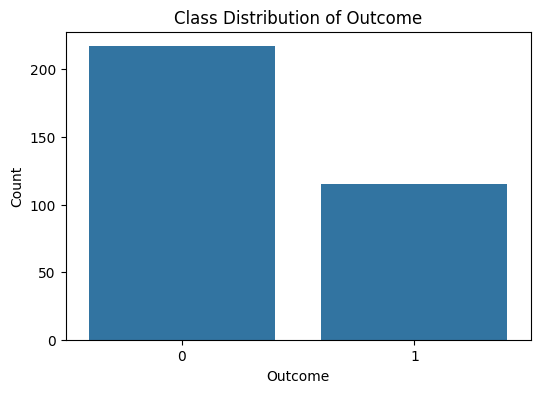

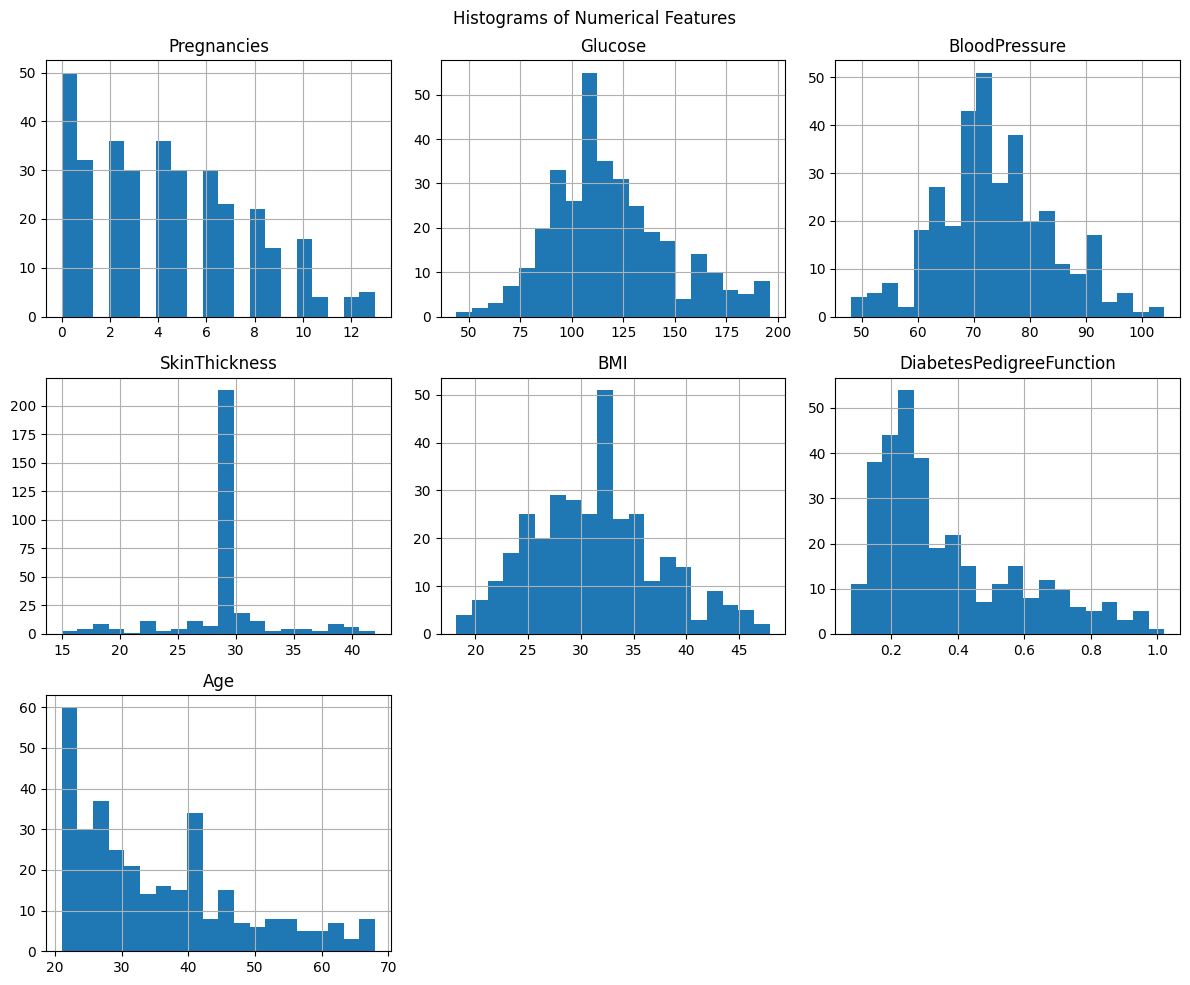

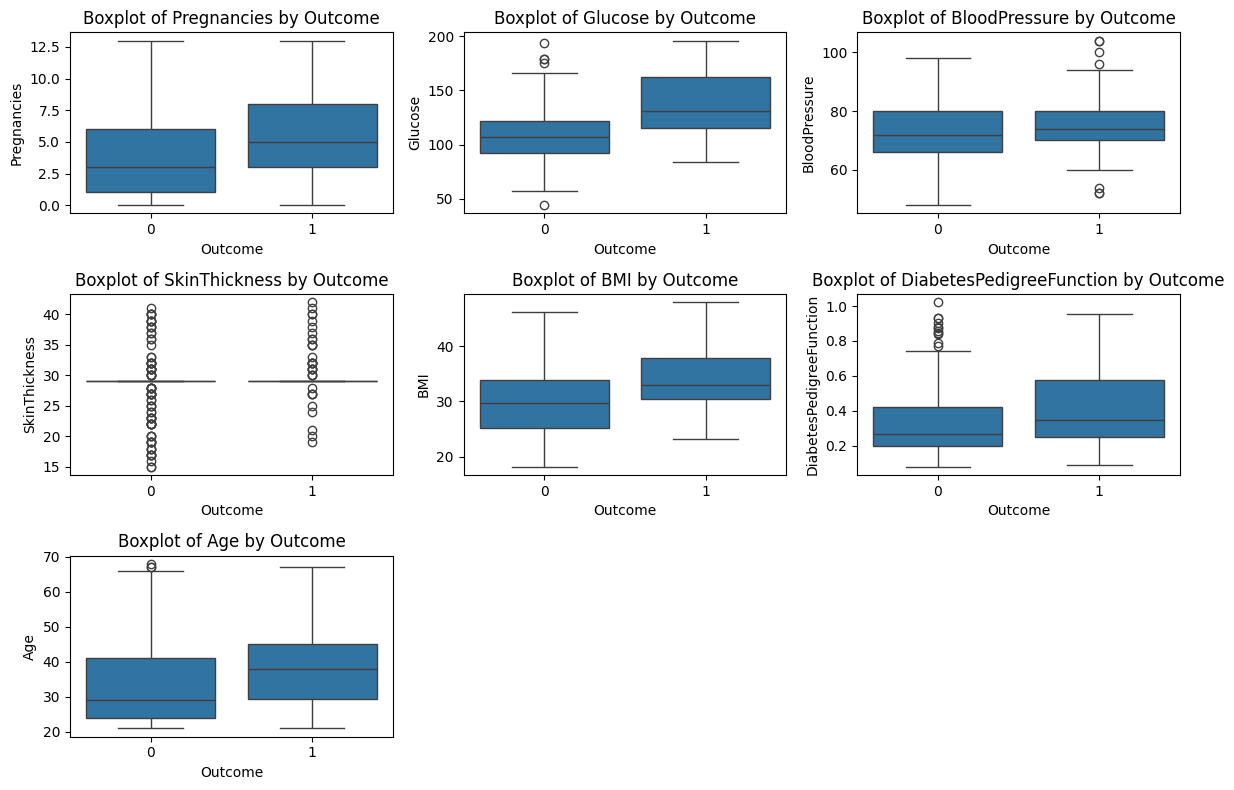

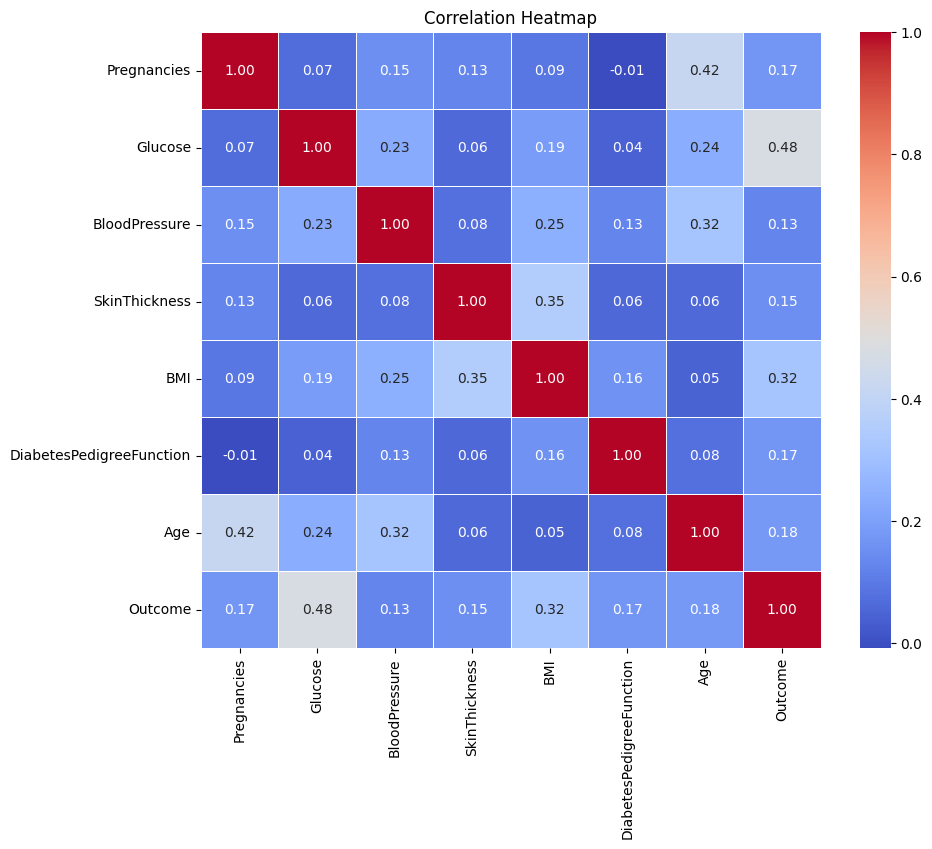

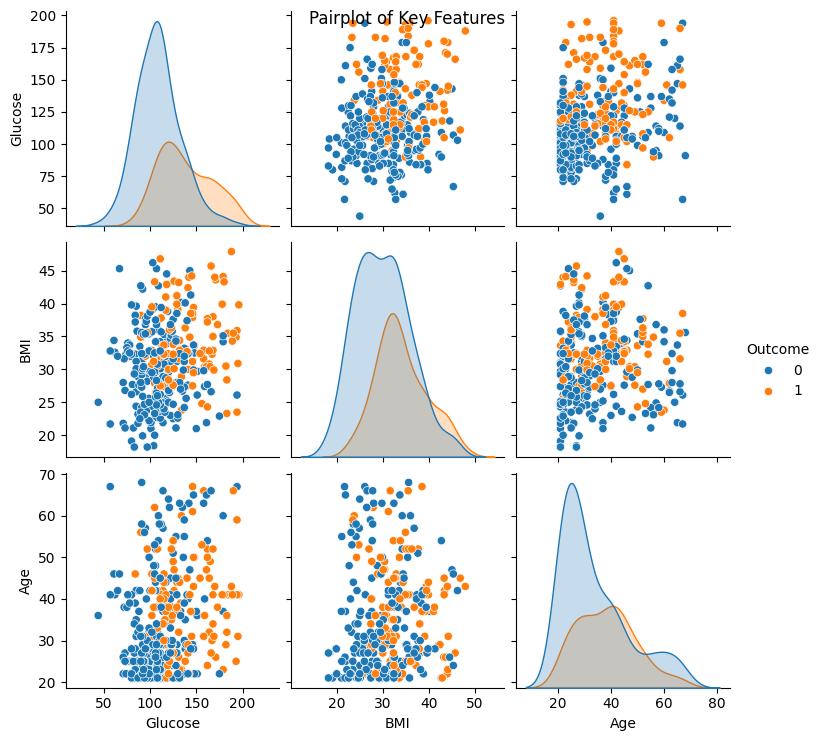


Key Correlations with Outcome:
Outcome                     1.000000
Glucose                     0.476102
BMI                         0.317324
Age                         0.178631
Pregnancies                 0.173130
DiabetesPedigreeFunction    0.172606
SkinThickness               0.151165
BloodPressure               0.126985
Name: Outcome, dtype: float64


In [7]:
# Conduct EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv('../data/Mugimba.csv')

# Drop Insulin column due to zero variance
df = df.drop('Insulin', axis=1)

# 1. Class Balance (Outcome: 0 = No Diabetes, 1 = Diabetes)
print("Class Balance:")
print(df['Outcome'].value_counts(normalize=True) * 100)  # Percentage

# Plot class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df)
plt.title('Class Distribution of Outcome')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

# 2. Feature Distributions (Histograms for numerical features)
numerical_cols = df.columns.drop('Outcome')  # All except target
df[numerical_cols].hist(bins=20, figsize=(12, 10), layout=(3, 3))
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout()
plt.show()

# 3. Boxplots to Check for Outliers (by Outcome)
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(f'Boxplot of {col} by Outcome')
plt.tight_layout()
plt.show()

# 4. Correlation Matrix (Pearson correlations)
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# 5. Pairplot for Relationships (subset for speed; can adjust)
sns.pairplot(df[['Glucose', 'BMI', 'Age', 'Outcome']], hue='Outcome', diag_kind='kde')
plt.suptitle('Pairplot of Key Features')
plt.show()

# Optional: Summary of key insights (printed)
print("\nKey Correlations with Outcome:")
print(corr['Outcome'].sort_values(ascending=False))

Interpretation of Results
1. Glucose (0.476)

Strongest predictor

This is expected because blood glucose level is a primary indicator of diabetes.

2. BMI (0.317)

Moderate positive relationship.

Higher BMI increases diabetes risk.

3. Age (0.179)

Mild correlation.

Diabetes risk increases with age.

4. Pregnancies (0.173)

Slight correlation.

Possibly related to gestational diabetes risk factors.

5. DiabetesPedigreeFunction (0.173)

Represents genetic predisposition.

6. SkinThickness & BloodPressure

Weak correlations.

They may still contribute in multivariate models even if individually weak.

Key Insights
1. Glucose levels exhibit the strongest correlation with diabetes outcome, suggesting it is the most influential predictor variable.
2. BMI shows a moderate correlation, indicating obesity is a significant risk factor.
3. Age, pregnancies, and genetic predisposition have weaker but still relevant associations with diabetes risk.

vvvvv


--- Logistic Regression Evaluation ---
Accuracy: 0.7910
Precision: 0.6957
Recall: 0.6957
F1 Score: 0.6957
ROC-AUC: 0.8982


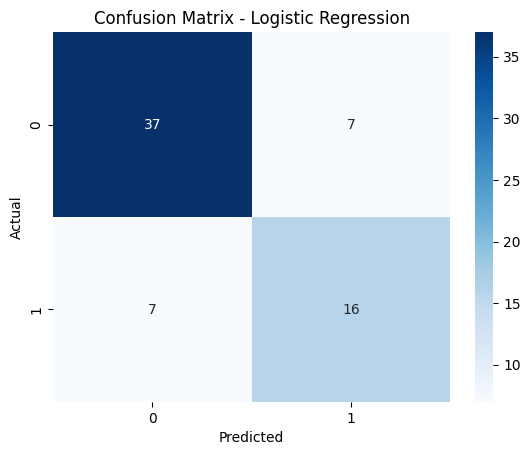


--- Random Forest Evaluation ---
Accuracy: 0.7761
Precision: 0.7222
Recall: 0.5652
F1 Score: 0.6341
ROC-AUC: 0.8463


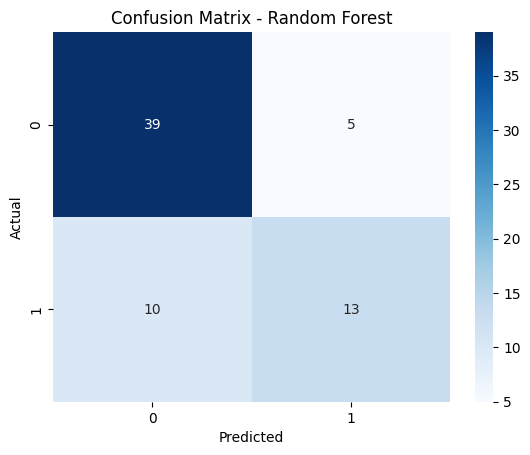

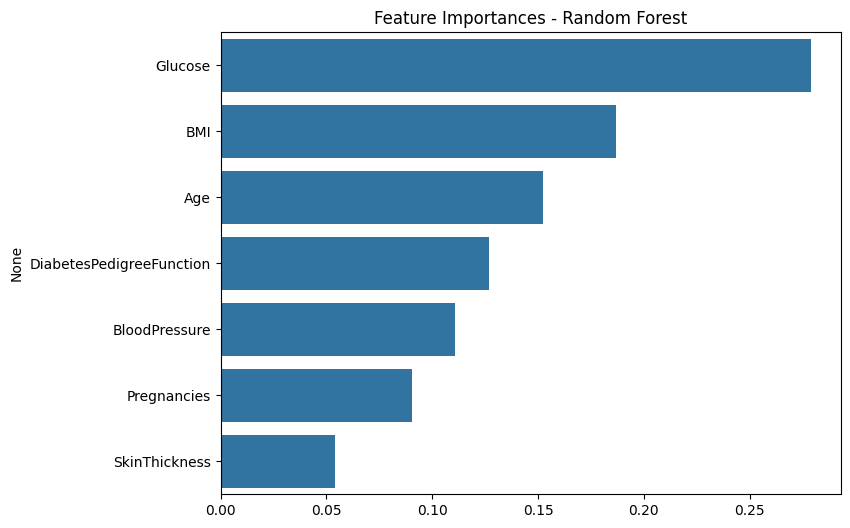

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model 1: Logistic Regression (with class weighting for imbalance)
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluation function
def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Evaluate both
evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")

# Feature Importances for Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importances - Random Forest')
plt.show()

Class Balance After SMOTE (Train):
Outcome
0    50.0
1    50.0
Name: proportion, dtype: float64
Best LR Params: {'C': 1, 'solver': 'lbfgs'}
Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

--- Logistic Regression (Tuned + SMOTE) Evaluation ---
Accuracy: 0.7910
Precision: 0.6800
Recall: 0.7391
F1 Score: 0.7083
ROC-AUC: 0.8804


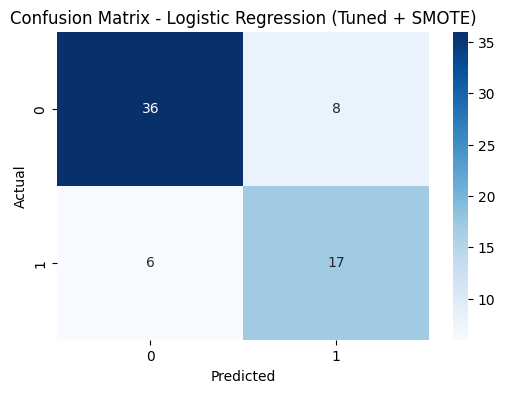


--- Random Forest (Tuned + SMOTE) Evaluation ---
Accuracy: 0.7761
Precision: 0.6667
Recall: 0.6957
F1 Score: 0.6809
ROC-AUC: 0.8399


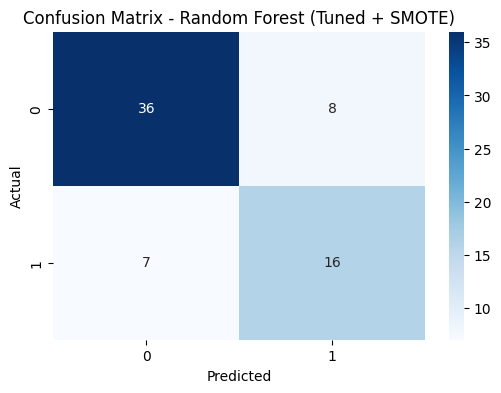

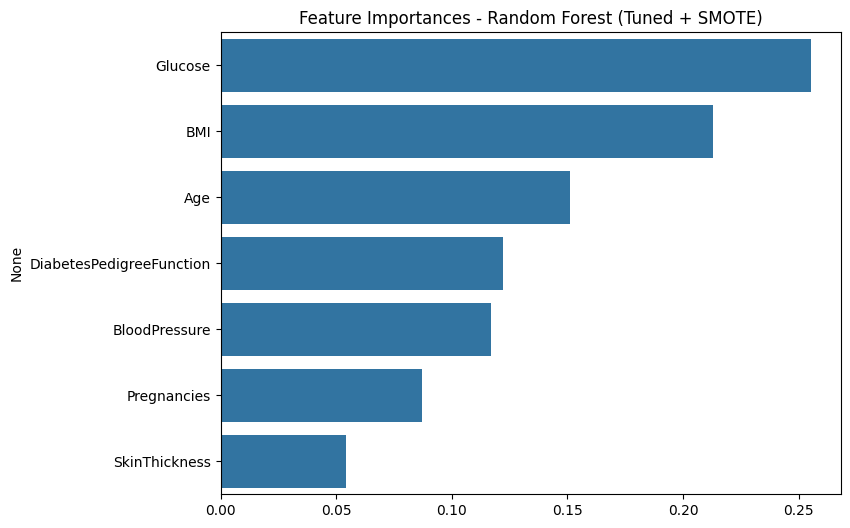

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# Load the cleaned dataset and drop Insulin (zero variance)
df = pd.read_csv('../data/Mugimba.csv').drop('Insulin', axis=1)

# Features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data (80/20, stratified for imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Print new class balance after SMOTE (for verification)
print("Class Balance After SMOTE (Train):")
print(y_train_res.value_counts(normalize=True) * 100)

# Model 1: Logistic Regression with hyperparameter tuning
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
                       lr_param_grid, cv=5, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train_res, y_train_res)
lr_best = lr_grid.best_estimator_
print(f"Best LR Params: {lr_grid.best_params_}")

y_pred_lr = lr_best.predict(X_test)
y_prob_lr = lr_best.predict_proba(X_test)[:, 1]

# Model 2: Random Forest with hyperparameter tuning
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42),
                       rf_param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_res, y_train_res)
rf_best = rf_grid.best_estimator_
print(f"Best RF Params: {rf_grid.best_params_}")

y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

# Evaluation function
def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Evaluate both models
evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression (Tuned + SMOTE)")
evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest (Tuned + SMOTE)")

# Feature Importances for Random Forest
importances = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importances - Random Forest (Tuned + SMOTE)')
plt.show()

# Save the best model as Mugimba_best_model.pkl

In [ ]:
import joblib


# lr_best is the tuned Logistic Regression
joblib.dump(lr_best, '../models/Mugimba_best_model.pkl')
print("Best model saved as '../models/Mugimba_best_model.pkl'")

Best model saved as '../models/Mugimba_best_model.pkl'
